In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'

In [19]:
store_base_path = (
    os.path.dirname(os.path.abspath("")) + "/data/results_npz/"   
)
figures_base_path = os.path.dirname(os.path.abspath("")) + "/figures/paper/"

In [20]:
original_data = np.load(store_base_path + "original.npz")
empty_16_data = np.load(store_base_path + "empty-16.npz")
empty_32_data = np.load(store_base_path + "empty-32.npz")
maze_32_data = np.load(store_base_path + "maze-32.npz")
dense_data = np.load(store_base_path + "dense.npz")
boston_harbor_data = np.load(store_base_path + "boston-harbor.xyz.npz")
# galvestonbay_data = np.load(store_base_path + "galveston-bay.xyz.npz")

In [21]:
def plot_box_plots(data, axis, title):

    bplot = axis.boxplot(data,
                            notch=False,
                            vert=True,
                            patch_artist=True)

    colors = ['pink', 'lightblue', 'lightgreen', 'orange']
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    fontsize = 10

    if "empty_16" in title:
        axis.set_title("Empty (16x16) \n" + r"$|\mathcal{A}| = 3, N = 5, H = 50$", fontsize=fontsize)
    elif "empty_32" in title:
        axis.set_title("Empty (32x32) \n" + r"$|\mathcal{A}| = 4, N = 10, H = 100$", fontsize=fontsize)
    elif "maze_32" in title:
        axis.set_title("Maze (32x32) \n" + r"$|\mathcal{A}| = 4, N = 10, H = 100$", fontsize=fontsize)
    elif "dense" in title:
        axis.set_title("Dense (65x81) \n" + r"$|\mathcal{A}| = 4, N = 30, H = 150$", fontsize=fontsize)
    elif "boston" in title:
        axis.set_title("Boston Harbor \n" + r"$|\mathcal{A}| = 4, N = 10, H = 100$", fontsize=fontsize)
    elif "galveston" in title:
        axis.set_title("Galveston Bay \n" + r"$|\mathcal{A}| = 4, N = 20, H = 150$", fontsize=fontsize)
    axis.yaxis.grid(True)
    axis.set_xticks([y+1 for y in range(len(data))], )
    
    plt.setp(axis, xticks=[y+1 for y in range(len(data))],
            xticklabels=['SA-V', 'SA-V-CA', 'MA-MCTS-V', 'MA-V'])
    

### First GP step - MAPF Benchmarks

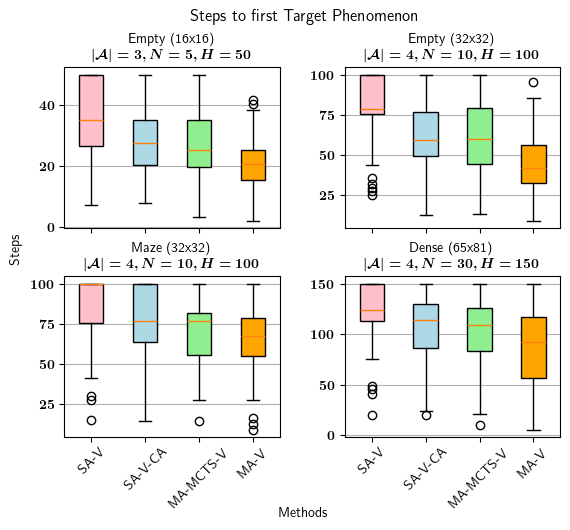

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)
plot_box_plots([empty_16_data["single_agent_first_gp_steps"], empty_16_data["single_agent_ca_first_gp_steps"], empty_16_data["multi_agent_mcts_first_gp_steps"], empty_16_data["multi_agent_first_gp_steps"]], axes[0, 0], "empty_16")
plot_box_plots([empty_32_data["single_agent_first_gp_steps"], empty_32_data["single_agent_ca_first_gp_steps"], empty_32_data["multi_agent_mcts_first_gp_steps"], empty_32_data["multi_agent_first_gp_steps"]], axes[0, 1], "empty_32")
plot_box_plots([maze_32_data["single_agent_first_gp_steps"], maze_32_data["single_agent_ca_first_gp_steps"], maze_32_data["multi_agent_mcts_first_gp_steps"], maze_32_data["multi_agent_first_gp_steps"]], axes[1, 0], "maze_32")
plot_box_plots([dense_data["single_agent_first_gp_steps"], dense_data["single_agent_ca_first_gp_steps"], dense_data["multi_agent_mcts_first_gp_steps"], dense_data["multi_agent_first_gp_steps"]], axes[1, 1], "dense")
for ax in axes[1, :]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# axes[0, 0].axhline(y=50, color='r', linestyle='--')
# axes[0, 1].axhline(y=100, color='r', linestyle='--')
# axes[1, 0].axhline(y=100, color='r', linestyle='--')
# axes[1, 1].axhline(y=150, color='r', linestyle='--')

fig.suptitle("Steps to first Target Phenomenon", y=1.0, fontsize=12)
fig.text(0.5, -0.05, 'Methods', ha='center', va='center')
fig.text(0.04, 0.5, 'Steps', va='center', rotation='vertical')
fig.subplots_adjust(wspace=0.3, hspace=0.3)

plt.savefig(figures_base_path + "first_gp_steps_mapf.svg")

### First GP step - Realistic Bathymetry Datasets

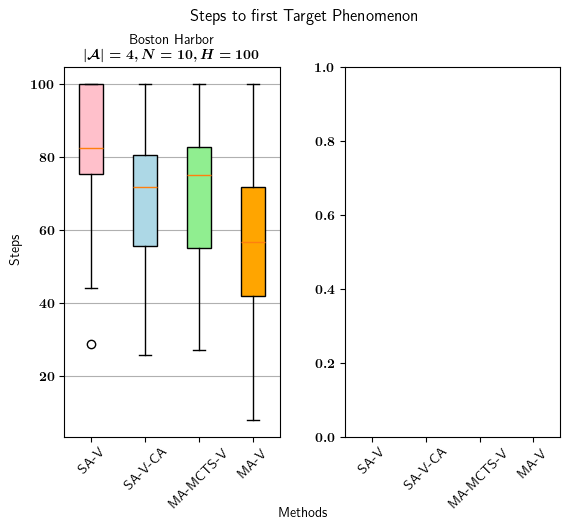

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True)
plot_box_plots([boston_harbor_data["single_agent_first_gp_steps"], boston_harbor_data["single_agent_ca_first_gp_steps"], boston_harbor_data["multi_agent_mcts_first_gp_steps"], boston_harbor_data["multi_agent_first_gp_steps"]], axes[0], "boston_harbor")
# plot_box_plots([galveston_bay_data["single_agent_first_gp_steps"], galveston_bay_data["single_agent_ca_first_gp_steps"], galveston_bay_data["multi_agent_mcts_first_gp_steps"], galveston_bay_data["multi_agent_first_gp_steps"]], axes[1], "galveston_bay")
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# axes[0].axhline(y=100, color='r', linestyle='--')
# axes[1].axhline(y=150, color='r', linestyle='--')

fig.suptitle("Steps to first Target Phenomenon", y=1.0, fontsize=12)
fig.text(0.5, -0.05, 'Methods', ha='center', va='center')
fig.text(0.04, 0.5, 'Steps', va='center', rotation='vertical')
fig.subplots_adjust(wspace=0.3)
plt.savefig(figures_base_path + "first_gp_steps_realistic.svg")

### Number of GPs discovered - MAPF Benchmarks

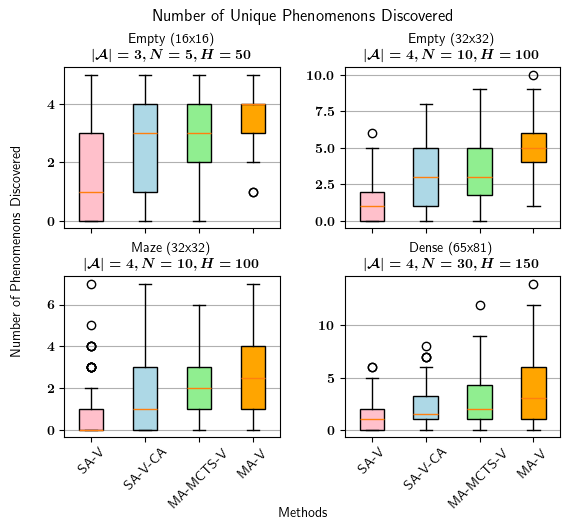

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)
plot_box_plots([empty_16_data["single_agent_phenomenons_discovered"], empty_16_data["single_agent_ca_phenomenons_discovered"], empty_16_data["multi_agent_mcts_phenomenons_discovered"], empty_16_data["multi_agent_phenomenons_discovered"]], axes[0, 0], "empty_16")
plot_box_plots([empty_32_data["single_agent_phenomenons_discovered"], empty_32_data["single_agent_ca_phenomenons_discovered"], empty_32_data["multi_agent_mcts_phenomenons_discovered"], empty_32_data["multi_agent_phenomenons_discovered"]], axes[0, 1], "empty_32")
plot_box_plots([maze_32_data["single_agent_phenomenons_discovered"], maze_32_data["single_agent_ca_phenomenons_discovered"], maze_32_data["multi_agent_mcts_phenomenons_discovered"], maze_32_data["multi_agent_phenomenons_discovered"]], axes[1, 0], "maze_32")
plot_box_plots([dense_data["single_agent_phenomenons_discovered"], dense_data["single_agent_ca_phenomenons_discovered"], dense_data["multi_agent_mcts_phenomenons_discovered"], dense_data["multi_agent_phenomenons_discovered"]], axes[1, 1], "dense")
for ax in axes[1, :]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# axes[0, 0].axhline(y=5, color='r', linestyle='--')
# axes[0, 1].axhline(y=10, color='r', linestyle='--')
# axes[1, 0].axhline(y=10, color='r', linestyle='--')
# axes[1, 1].axhline(y=30, color='r', linestyle='--')

fig.suptitle("Number of Unique Phenomenons Discovered", y=1.0, fontsize=12)
fig.text(0.5, -0.05, 'Methods', ha='center', va='center')
fig.text(0.04, 0.5, 'Number of Phenomenons Discovered', va='center', rotation='vertical')
fig.subplots_adjust(wspace=0.3, hspace=0.3)
plt.savefig(figures_base_path + "phenomenons_discovered_mapf.svg")

### Number of GPs discovered - Realistic Bathymetry Datasets

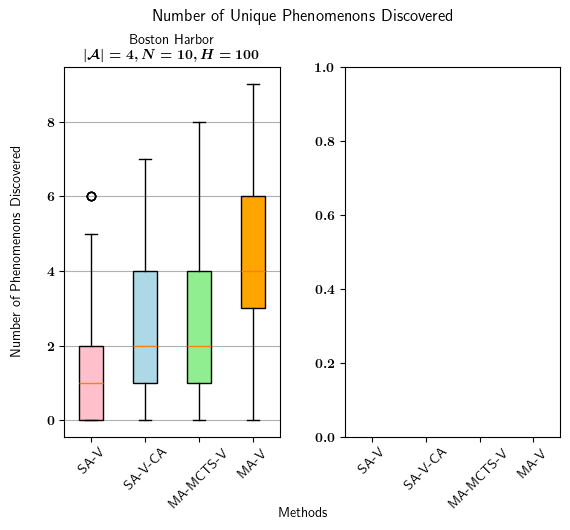

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True)
plot_box_plots([boston_harbor_data["single_agent_phenomenons_discovered"], boston_harbor_data["single_agent_ca_phenomenons_discovered"], boston_harbor_data["multi_agent_mcts_phenomenons_discovered"], boston_harbor_data["multi_agent_phenomenons_discovered"]], axes[0], "boston_harbor")
# plot_box_plots([galveston_bay_data["single_agent_phenomenons_discovered"], galveston_bay_data["single_agent_ca_phenomenons_discovered"], galveston_bay_data["multi_agent_mcts_phenomenons_discovered"], galveston_bay_data["multi_agent_phenomenons_discovered"]], axes[1], "galveston_bay")
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# axes[0].axhline(y=10, color='r', linestyle='--')
# axes[1].axhline(y=10, color='r', linestyle='--')

fig.suptitle("Number of Unique Phenomenons Discovered", y=1.0, fontsize=12)
fig.text(0.5, -0.05, 'Methods', ha='center', va='center')
fig.text(0.04, 0.5, 'Number of Phenomenons Discovered', va='center', rotation='vertical')
fig.subplots_adjust(wspace=0.3)
plt.savefig(figures_base_path + "phenomenons_discovered_realistic.svg")

### Nodes Analysis

Text(0.5, 0, '\n\nMaps')

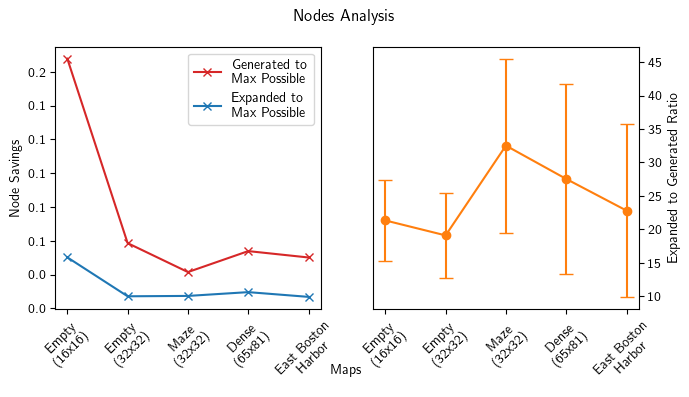

In [26]:
from matplotlib.ticker import FuncFormatter
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(7, 4))

empty_16_gen_to_max = empty_16_data["max_possible_nodes_data"][0] / empty_16_data["max_possible_nodes_data"][-1]
empty_32_gen_to_max = empty_32_data["max_possible_nodes_data"][0] / empty_32_data["max_possible_nodes_data"][-1]
maze_32_gen_to_max = maze_32_data["max_possible_nodes_data"][0] / maze_32_data["max_possible_nodes_data"][-1]
dense_gen_to_max = dense_data["max_possible_nodes_data"][0] / dense_data["max_possible_nodes_data"][-1]
boston_harbor_data_gen_to_max = boston_harbor_data["max_possible_nodes_data"][0] / boston_harbor_data["max_possible_nodes_data"][-1]
# galveston_bay_data_gen_to_max = galveston_bay_data["max_possible_nodes_data"][0] / galveston_bay_data["max_possible_nodes_data"][-1]

empty_16_exp_to_max = empty_16_data["max_possible_nodes_data"][1] / empty_16_data["max_possible_nodes_data"][-1]
empty_32_exp_to_max = empty_32_data["max_possible_nodes_data"][1] / empty_32_data["max_possible_nodes_data"][-1]
maze_32_exp_to_max = maze_32_data["max_possible_nodes_data"][1] / maze_32_data["max_possible_nodes_data"][-1]
dense_exp_to_max = dense_data["max_possible_nodes_data"][1] / dense_data["max_possible_nodes_data"][-1]
boston_harbor_data_exp_to_max = boston_harbor_data["max_possible_nodes_data"][1] / boston_harbor_data["max_possible_nodes_data"][-1]
# galveston_bay_data_exp_to_max = galveston_bay_data["max_possible_nodes_data"][1] / galveston_bay_data["max_possible_nodes_data"][-1]

# gen_to_max_data = [empty_16_gen_to_max, empty_32_gen_to_max, maze_32_gen_to_max, dense_gen_to_max, boston_harbor_data_gen_to_max, galveston_bay_data_gen_to_max]
# exp_to_max_data = [empty_16_exp_to_max, empty_32_exp_to_max, maze_32_exp_to_max, dense_exp_to_max, boston_harbor_data_exp_to_max, galveston_bay_data_exp_to_max]
gen_to_max_data = [empty_16_gen_to_max, empty_32_gen_to_max, maze_32_gen_to_max, dense_gen_to_max, boston_harbor_data_gen_to_max]
exp_to_max_data = [empty_16_exp_to_max, empty_32_exp_to_max, maze_32_exp_to_max, dense_exp_to_max, boston_harbor_data_exp_to_max]
x = np.arange(len(gen_to_max_data))

axes[0].set_ylabel('Node Savings')
axes[0].plot(x, gen_to_max_data, color='tab:red', marker="x", label = "Generated to \n Max Possible")
axes[0].plot(x, exp_to_max_data, color='tab:blue', marker="x", label = "Expanded to \n Max Possible")
axes[0].tick_params(axis='y')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
axes[0].legend()

empty_16_ratio_mean, empty_16_ratio_std = np.mean(empty_16_data["ratios"]), np.std(empty_16_data["ratios"])
empty_32_ratio_mean, empty_32_ratio_std = np.mean(empty_32_data["ratios"]), np.std(empty_32_data["ratios"])
maze_32_ratio_mean, maze_32_ratio_std = np.mean(maze_32_data["ratios"]), np.std(maze_32_data["ratios"])
dense_ratio_mean, dense_ratio_std = np.mean(dense_data["ratios"]), np.std(dense_data["ratios"])
boston_harbor_data_ratio_mean, boston_harbor_data_ratio_std = np.mean(boston_harbor_data["ratios"]), np.std(boston_harbor_data["ratios"])
# galveston_bay_data_ratio_mean, galveston_bay_data_ratio_std = np.mean(galveston_bay_data["ratios"]), np.std(galveston_bay_data["ratios"])

# ratio_mean, ration_std = [empty_16_ratio_mean, empty_32_ratio_mean, maze_32_ratio_mean, dense_ratio_mean, boston_harbor_data_ratio_mean, galveston_bay_data_ratio_mean], [empty_16_ratio_std, empty_32_ratio_std, maze_32_ratio_std, dense_ratio_std, boston_harbor_data_ratio_std, galveston_bay_data_ratio_std]
ratio_mean, ration_std = [empty_16_ratio_mean, empty_32_ratio_mean, maze_32_ratio_mean, dense_ratio_mean, boston_harbor_data_ratio_mean], [empty_16_ratio_std, empty_32_ratio_std, maze_32_ratio_std, dense_ratio_std, boston_harbor_data_ratio_std]

axes[1].set_ylabel('Expanded to Generated Ratio')
axes[1].errorbar(x, ratio_mean, ration_std, fmt='o-', capsize=5, color='tab:orange')
axes[1].tick_params(axis='y')
axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

# xticklabels = ['Empty \n (16x16)', 'Empty \n (32x32)', 'Maze \n (32x32)', 'Dense \n (65x81)', 'East Boston \n Harbor', 'Galveston Bay']
xticklabels = ['Empty \n (16x16)', 'Empty \n (32x32)', 'Maze \n (32x32)', 'Dense \n (65x81)', 'East Boston \n Harbor']

plt.setp(axes[0], xticks=[y for y in range(len(gen_to_max_data))],
        xticklabels=xticklabels)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

fig.suptitle("Nodes Analysis")
fig.tight_layout()
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("\n\nMaps")

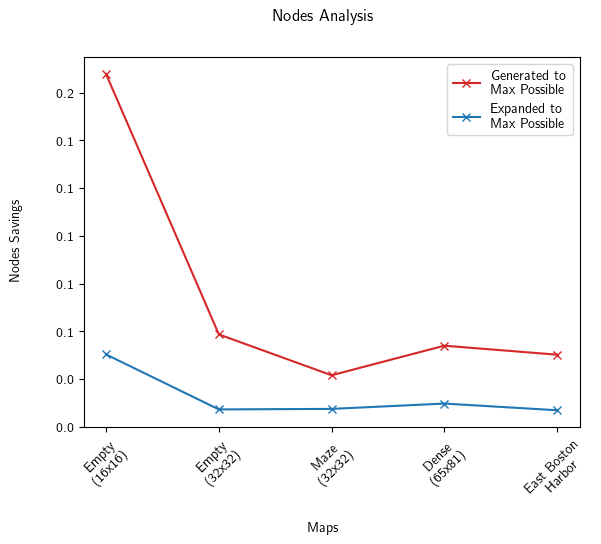

In [27]:
from matplotlib.ticker import FuncFormatter
fig, axes = plt.subplots()

empty_16_gen_to_max = empty_16_data["max_possible_nodes_data"][0] / empty_16_data["max_possible_nodes_data"][-1]
empty_32_gen_to_max = empty_32_data["max_possible_nodes_data"][0] / empty_32_data["max_possible_nodes_data"][-1]
maze_32_gen_to_max = maze_32_data["max_possible_nodes_data"][0] / maze_32_data["max_possible_nodes_data"][-1]
# dense_gen_to_max = dense_data["max_possible_nodes_data"][0] / dense_data["max_possible_nodes_data"][-1]
boston_harbor_data_gen_to_max = boston_harbor_data["max_possible_nodes_data"][0] / boston_harbor_data["max_possible_nodes_data"][-1]
# galveston_bay_data_gen_to_max = galveston_bay_data["max_possible_nodes_data"][0] / galveston_bay_data["max_possible_nodes_data"][-1]

empty_16_exp_to_max = empty_16_data["max_possible_nodes_data"][1] / empty_16_data["max_possible_nodes_data"][-1]
empty_32_exp_to_max = empty_32_data["max_possible_nodes_data"][1] / empty_32_data["max_possible_nodes_data"][-1]
maze_32_exp_to_max = maze_32_data["max_possible_nodes_data"][1] / maze_32_data["max_possible_nodes_data"][-1]
# dense_exp_to_max = dense_data["max_possible_nodes_data"][1] / dense_data["max_possible_nodes_data"][-1]
boston_harbor_data_exp_to_max = boston_harbor_data["max_possible_nodes_data"][1] / boston_harbor_data["max_possible_nodes_data"][-1]
# galveston_bay_data_exp_to_max = galveston_bay_data["max_possible_nodes_data"][1] / galveston_bay_data["max_possible_nodes_data"][-1]

# gen_to_max_data = [empty_16_gen_to_max, empty_32_gen_to_max, maze_32_gen_to_max, dense_gen_to_max, boston_harbor_data_gen_to_max, galveston_bay_data_gen_to_max]
# exp_to_max_data = [empty_16_exp_to_max, empty_32_exp_to_max, maze_32_exp_to_max, dense_exp_to_max, boston_harbor_data_exp_to_max, galveston_bay_data_exp_to_max]
gen_to_max_data = [empty_16_gen_to_max, empty_32_gen_to_max, maze_32_gen_to_max, dense_gen_to_max, boston_harbor_data_gen_to_max]
exp_to_max_data = [empty_16_exp_to_max, empty_32_exp_to_max, maze_32_exp_to_max, dense_exp_to_max, boston_harbor_data_exp_to_max]

x = np.arange(len(gen_to_max_data))

axes.plot(x, gen_to_max_data, color='tab:red', marker="x", label = "Generated to \n Max Possible")
axes.plot(x, exp_to_max_data, color='tab:blue', marker="x", label = "Expanded to \n Max Possible")
axes.tick_params(axis='y')
axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
axes.legend()

# xticklabels = ['Empty \n (16x16)', 'Empty \n (32x32)', 'Maze \n (32x32)', 'Dense \n (65x81)', 'East Boston \n Harbor', 'Galveston Bay']
xticklabels = ['Empty \n (16x16)', 'Empty \n (32x32)', 'Maze \n (32x32)', 'Dense \n (65x81)', 'East Boston \n Harbor']

plt.setp(axes, xticks=[y for y in range(len(gen_to_max_data))],
        xticklabels=xticklabels)

for label in axes.get_xticklabels():
        label.set_rotation(45)

fig.suptitle("Nodes Analysis")
fig.text(0.5, -0.1, 'Maps', ha='center', va='center')
fig.text(0.01, 0.5, 'Nodes Savings', va='center', rotation='vertical')
fig.subplots_adjust(wspace=0.3)

plt.savefig(figures_base_path + "nodes_analysis.svg")